---
title: Activity Custom Dataset
---

# YOLOv8 Object Detection: Laptop and Cell Phone

**Name:** Rosemarie Ann S. Bajao  
**Course:** BS Data Science  
**Activity:** Custom Dataset

---

## Overview

This task explores the use of a pretrained YOLOv8 model for object detection. The model is used to identify two everyday objects, laptops and cell phones, from images in the dataset.

YOLO performs object detection, which allows it to identify an object and locate it using a bounding box. No additional model training is performed in this activity. The pretrained YOLOv8 model is directly used for prediction and evaluation.

**Import Libraries**

In [2]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt

# !pip install ultralytics -q

from ultralytics import YOLO

In [3]:
os.listdir('dataset')

['0', '1']

In [4]:
root = 'dataset'

In [5]:
data_dict = {'X': [], 'y': []}

for cls in sorted(os.listdir(root)):
    cls_path = os.path.join(root, cls)

    if not os.path.isdir(cls_path):
        continue

    for img in sorted(os.listdir(cls_path)):
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(int(cls))

data = pd.DataFrame(data_dict)
data

,X,y
0,dataset\0\acer nitro 16.jpg,0
1,dataset\0\asus rog strix g 2019.jpg,0
2,dataset\0\legion 5 pro.jpg,0
3,dataset\1\honor x6.jpg,1
4,dataset\1\huawei phone.png,1
5,dataset\1\vivo v30e.png,1


**Load the Pretrained YOLOv8 Model**

In [6]:
model = YOLO('yolov8n.pt')

In [7]:
classes = model.names

print('Class 63:', classes[63])
print('Class 67:', classes[67])

Class 63: laptop
Class 67: cell phone


In [8]:
image_path = data_dict['X'][1]
print(image_path)

dataset\0\asus rog strix g 2019.jpg


In [9]:
result = model.predict(
    image_path,
    classes=[63, 67],
    conf=0.25,
    verbose=False
)[0]

In [10]:
if len(result.boxes) > 0:
    best_box = max(result.boxes, key=lambda b: float(b.conf[0]))

    predicted_class_id = int(best_box.cls[0])
    confidence = float(best_box.conf[0])

    print('Predicted class:', classes[predicted_class_id])
    print(f'Confidence: {confidence:.2%}')
else:
    predicted_class_id = None
    confidence = 0

    print('No laptop or cell phone detected.')

No laptop or cell phone detected.


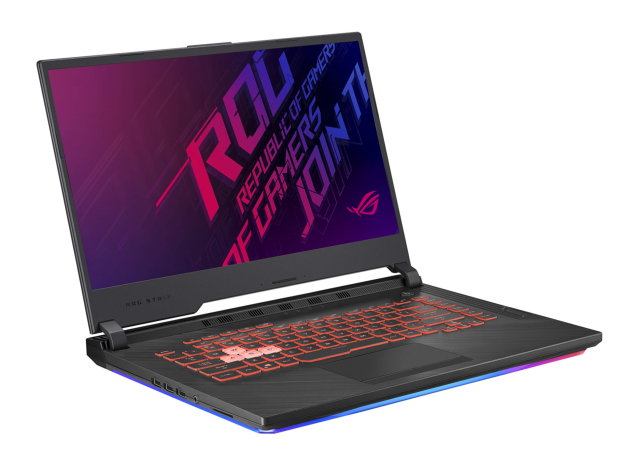

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(result.plot()[:, :, ::-1])
plt.axis('off')
plt.show()

In [13]:
yolo_to_dataset_label = {
    63: 0,  # laptop
    67: 1   # cell phone
}

results = model.predict(
    data_dict['X'],
    classes=[63, 67],
    conf=0.25,
    verbose=False
)

records = []

for i, result in enumerate(results):
    true_label = data_dict['y'][i]

    if len(result.boxes) == 0:
        predicted_label = None
        predicted_name = 'No detection'
        confidence = 0
    else:
        best_box = max(result.boxes, key=lambda b: float(b.conf[0]))

        cls_id = int(best_box.cls[0])
        confidence = float(best_box.conf[0])

        predicted_label = yolo_to_dataset_label[cls_id]
        predicted_name = classes[cls_id]

    is_correct = predicted_label == true_label

    records.append({
        'Image': os.path.basename(data_dict['X'][i]),
        'True Label': 'Laptop' if true_label == 0 else 'Cell phone',
        'Predicted Label': predicted_name,
        'Confidence': confidence,
        'Correct': is_correct
    })

evaluation = pd.DataFrame(records)
evaluation

,Image,True Label,Predicted Label,Confidence,Correct
0,acer nitro 16.jpg,Laptop,laptop,0.785642,True
1,asus rog strix g 2019.jpg,Laptop,laptop,0.405196,True
2,legion 5 pro.jpg,Laptop,laptop,0.871883,True
3,honor x6.jpg,Cell phone,No detection,0.000000,False
4,huawei phone.png,Cell phone,No detection,0.000000,False
5,vivo v30e.png,Cell phone,No detection,0.000000,False


In [14]:
correct = int(evaluation['Correct'].sum())
total = len(evaluation)

accuracy = correct / total if total > 0 else 0

print(f'Correct predictions: {correct}/{total}')
print(f'Accuracy: {accuracy:.2%}')

Correct predictions: 3/6
Accuracy: 50.00%


In [15]:
class_results = (
    evaluation
    .groupby('True Label')['Correct']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Correct', 'count': 'Total'})
)

class_results['Accuracy'] = class_results['Correct'] / class_results['Total']
class_results

,Correct,Total,Accuracy
True Label,,,
Cell phone,0,3,0.0
Laptop,3,3,1.0


The accuracy represents the performance of the pretrained YOLOv8 model on the images included in this dataset. Images with no detected laptop or cell phone are counted as incorrect predictions.

The result applies only to the given dataset and should not be interpreted as the overall accuracy of YOLOv8. YOLO can also be used on real-world images, such as a laptop on a desk or a phone on a table, where it can identify the object and show its location using a bounding box.